# Clasical ML model selection - All features

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

Run with all features...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE, index_col=0)

print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1154, 83)
X Columns: ['age', 'height', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_diff_ankle_df_peak_angle', 'dom_leg_ankle_eve_excursion', 'dom_leg_diff_ankle_eve_excursion', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_peak_vel', 'dom_leg_ankle_eve_percent_stance', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_angle', 'dom_leg_diff_ankle_rot_peak_angle', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_diff_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_foot_prog_angle', 'dom_leg_diff_foot_prog_angle', 'dom_leg_hip_abd_peak_vel', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_hip_add_excursion', 'dom_leg_diff_hip_add_excursion', 'dom_leg_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_hip_add_peak_vel', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak

,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,-0.623476,1.118091,0.633105,1.099834,0.479364,1.447539,0.504055,1.352344,...,0.033290,-0.825146,-0.024152,0.518204,-0.295909,0.227493,1.094980,0.557382,0.334735,0.0
100002_20110601T140505,-0.150620,0.088511,0.000005,1.186679,-0.769343,1.435292,1.369072,-0.891457,-0.128827,0.772460,...,0.033290,-0.284462,-0.024152,-0.383164,2.374306,0.494990,1.801695,-0.052167,-1.015686,1.0
100004_20110203T120721,-0.326281,0.318975,-0.831303,1.097380,-0.611548,0.454303,-0.454533,0.952733,0.213660,-0.265570,...,0.033290,-0.171882,-0.024152,-1.184380,-0.809412,0.361241,-1.378523,0.321218,0.936946,1.0
100004_20140929T102035,0.025040,0.256121,-0.687974,1.200187,-0.597585,-0.496600,-1.646722,-1.235893,-0.149788,-1.023207,...,-2.375712,0.057971,2.242683,-1.284532,-0.398610,-0.173754,-0.671808,0.006865,1.274719,1.0
100005_20110208T120837,-0.501941,-1.336177,-0.974632,0.700173,-0.055702,1.219604,0.074521,-0.082042,-0.504754,0.652176,...,0.033290,1.723083,-0.024152,-1.484836,-0.398610,-1.511240,0.388265,-1.061532,-0.356889,1.0


Y Dataset shape: (1154, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100002_20110601T140505,True
100004_20110203T120721,True
100004_20140929T102035,False
100005_20110208T120837,True


Class distribution: is_injured
True     838
False    316
Name: count, dtype: int64
Class distribution: is_injured
True     0.72617
False    0.27383
Name: proportion, dtype: float64


In [3]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': np.logspace(-3, 3, 7),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear', 'saga']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10, 16],
            'classifier__min_samples_leaf': [2, 5, 8],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', max_delta_step=1))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [neg_pos_ratio]  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma': ['scale', 0.1, 0.01]
        }
    }
}

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold


cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
subject_ids = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

for model_name, config in models_config.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)
    
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        cv=cv.split(X_train, y_train, groups=subject_ids),
        #cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    
    grid_search.fit(X_train, y_train)
    
    trained_models[model_name] = grid_search
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_,
    }
    
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")


Training Logistic Regression...
Fitting 5 folds for each of 28 candidates, totalling 140 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConv

Best CV Score: 0.6240
Best Parameters: {'classifier__C': 100.0, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}

Training Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Docume

Best CV Score: 0.6998
Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Training XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV Score: 0.6965
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'classifier__scale_pos_weight': 2.651898734177215, 'classifier__subsample': 1.0}

Training SVM...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConv

Best CV Score: 0.7352
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE, index_col=0)

X = X_test
y = y_test

for model_name, model in trained_models.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)

    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)

    best_train_score = np.max(model.cv_results_['mean_train_score'])
    test_accuracy = accuracy_score(y, y_pred)
    test_precision = precision_score(y, y_pred, average='weighted')
    test_recall = recall_score(y, y_pred, average='weighted')
    test_f1 = f1_score(y, y_pred, average='weighted')
    test_roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
    
    results[model_name].update({
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })
    
    print("Validation results:")
    print(f"Best CV Score: {model.best_score_:.4f}")
    print(f"Best Train Score: {best_train_score:.4f}")
    print(f"Best Parameters: {model.best_params_}")
    print("\nTest results:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"Test ROC AUC: {test_roc_auc:.4f}")


Training Logistic Regression...
Validation results:
Best CV Score: 0.6240
Best Train Score: 0.7684
Best Parameters: {'classifier__C': 100.0, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}

Test results:
Test Accuracy: 0.5296
Test Precision: 0.5883
Test Recall: 0.5296
Test F1-Score: 0.5513
Test ROC AUC: 0.5060

Training Random Forest...
Validation results:
Best CV Score: 0.6998
Best Train Score: 1.0000
Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Test results:
Test Accuracy: 0.7317
Test Precision: 0.8042
Test Recall: 0.7317
Test F1-Score: 0.6251
Test ROC AUC: 0.5949

Training XGBoost...
Validation results:
Best CV Score: 0.6965
Best Train Score: 1.0000
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'classif

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
2              XGBoost        0.6076         0.7108          0.5935   
3                  SVM        0.6032         0.7247          0.5252   
1        Random Forest        0.5949         0.7317          0.8042   
0  Logistic Regression        0.5060         0.5296          0.5883   

   Test Recall  Test F1-Score  
2       0.7108         0.6139  
3       0.7247         0.6091  
1       0.7317         0.6251  
0       0.5296         0.5513  

Best performing model: XGBoost
Best Test ROC AUC Score: 0.6076


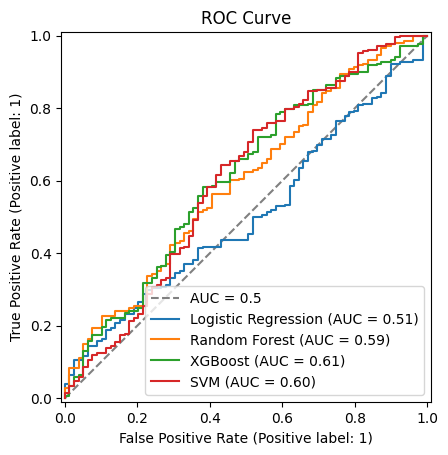

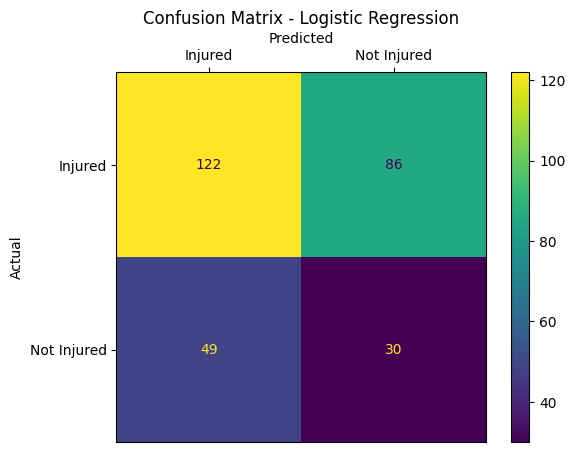

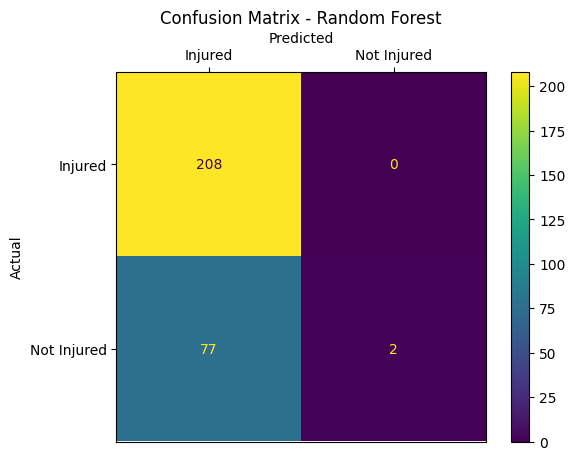

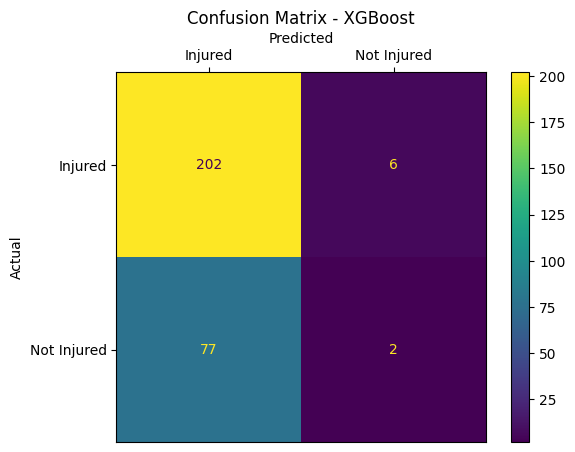

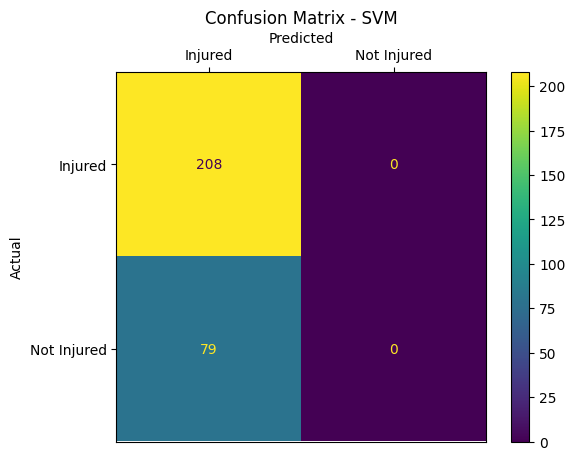

In [6]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['test_roc_auc'],
        'Test Accuracy': result['test_accuracy'],
        'Test Precision': result['test_precision'],
        'Test Recall': result['test_recall'],
        'Test F1-Score': result['test_f1'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'][:, 1], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")